<a href="https://colab.research.google.com/github/Supercoder2005/FSP/blob/main/FSP_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
file_path = '/content/sample_-_superstore.xls'
df = pd.read_excel(file_path)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


## Project Analysis Plan

Based on your request, I will perform the following analysis steps on the Superstore dataset:

1.  **Initial Data Inspection**: Get an overview of the dataset, data types, and missing values.
2.  **Data Cleaning/Preparation**: Convert date columns to appropriate formats.
3.  **Total Sales**: Calculate the overall total sales.
4.  **Best-Selling Products**: Identify products with the highest sales.
5.  **Monthly Revenue**: Calculate the total sales for each month.
6.  **Customer Trends**: Analyze customer segments and top customers.
7.  **Sales Performance**: Explore sales by region, category, and other relevant dimensions.

### 1. Initial Data Inspection

In [ ]:
print('--- DataFrame Info ---')
df.info()

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null 

In [ ]:
print('\n--- Descriptive Statistics ---')
df.describe(include='all')


--- Descriptive Statistics ---


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month
count,10194.000000,10194,10194,10194,10194,10194,10194,10194,10194,10194,...,10194,10194,10194,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000,10194
unique,NaN,5111,NaN,NaN,4,804,800,3,2,542,...,4,1862,3,17,1849,NaN,NaN,NaN,NaN,48
top,NaN,US-2026-100111,NaN,NaN,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,...,West,FUR-FU-10004270,Office Supplies,Binders,Staples,NaN,NaN,NaN,NaN,2026-12
freq,NaN,14,NaN,NaN,6120,41,41,5281,9994,915,...,3253,20,6128,1548,50,NaN,NaN,NaN,NaN,482
mean,5097.500000,NaN,2025-04-29 11:48:25.002942720,2025-05-03 10:52:45.626839296,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,228.225854,3.791838,0.155385,28.673417,NaN
min,1.000000,NaN,2023-01-03 00:00:00,2023-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000,NaN
25%,2549.250000,NaN,2024-05-14 00:00:00,2024-05-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,17.220000,2.000000,0.000000,1.760800,NaN
50%,5097.500000,NaN,2025-06-25 00:00:00,2025-06-28 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,53.910000,3.000000,0.200000,8.690000,NaN
75%,7645.750000,NaN,2026-05-14 00:00:00,2026-05-18 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,209.500000,5.000000,0.200000,29.297925,NaN
max,10194.000000,NaN,2026-12-30 00:00:00,2027-01-05 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,22638.480000,14.000000,0.800000,8399.976000,NaN


#Missing Value checking

In [ ]:
print('\n--- Missing Values ---')
df.isnull().sum()


--- Missing Values ---


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


### 2. Data Cleaning/Preparation

In [ ]:
# Convert 'Order Date' and 'Ship Date' to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print('Data types after conversion:')
df[['Order Date', 'Ship Date']].info()

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  10194 non-null  datetime64[ns]
 1   Ship Date   10194 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 159.4 KB


### 3. Total Sales

In [ ]:
total_sales = df['Sales'].sum()
print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,326,534.35


### 4. Best-Selling Products

In [ ]:
top_products_by_sales = df.groupby('Product Name')['Sales'].sum().nlargest(10)
print('Top 10 Best-Selling Products by Sales:')
display(top_products_by_sales)

Top 10 Best-Selling Products by Sales:


,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [ ]:
top_products_by_quantity = df.groupby('Product Name')['Quantity'].sum().nlargest(10)
print('\nTop 10 Best-Selling Products by Quantity:')
display(top_products_by_quantity)


Top 10 Best-Selling Products by Quantity:


,Quantity
Product Name,
Staples,234
Staple envelope,170
Easy-staple paper,150
Staples in misc. colors,86
Nu-Dell Executive Frame,84
KI Adjustable-Height Table,79
GBC DocuBind P50 Personal Binding Machine,72
Avery Non-Stick Binders,71
Storex Dura Pro Binders,71


### 5. Monthly Revenue

In [ ]:
df['Order Month'] = df['Order Date'].dt.to_period('M')
monthly_revenue = df.groupby('Order Month')['Sales'].sum()
print('Monthly Revenue:')
display(monthly_revenue)

Monthly Revenue:


,Sales
Order Month,
2023-01,14518.0550
2023-02,4519.8920
2023-03,56933.9090
2023-04,28295.3450
2023-05,26319.7670
2023-06,34669.4796
2023-07,33946.3930
2023-08,28918.3385
2023-09,82670.4288


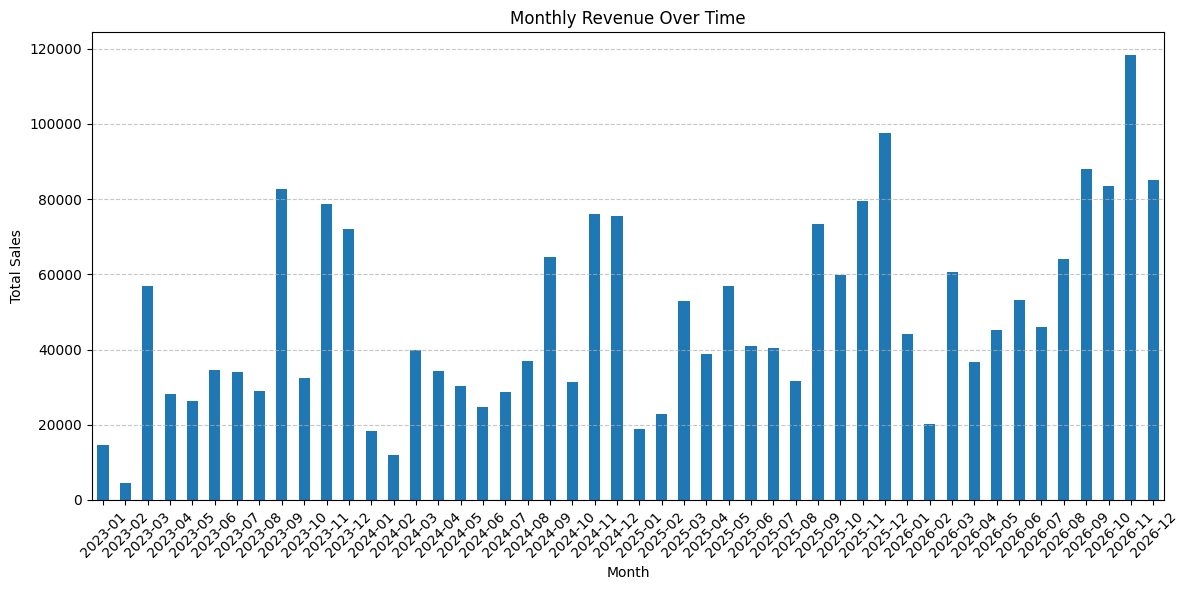

In [ ]:
# Plotting monthly revenue
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='bar')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 6. Customer Trends

In [ ]:
top_customers_by_sales = df.groupby('Customer Name')['Sales'].sum().nlargest(10)
print('Top 10 Customers by Sales:')
display(top_customers_by_sales)

Top 10 Customers by Sales:


,Sales
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
Ken Lonsdale,14175.229
Sanjit Chand,14142.334
Hunter Lopez,12873.298
Sanjit Engle,12209.438


In [ ]:
# Sales by Segment
sales_by_segment = df.groupby('Segment')['Sales'].sum()
print('\nSales by Customer Segment:')
print(sales_by_segment.apply(lambda x: f"{x:,.2f}"))



Sales by Customer Segment:
Segment
Consumer       1,170,659.79
Corporate        715,806.13
Home Office      440,068.43
Name: Sales, dtype: object


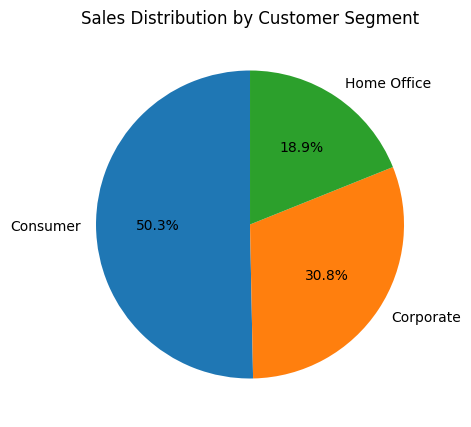

In [ ]:
# Plotting sales by segment
plt.figure(figsize=(8, 5))
sales_by_segment.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Sales Distribution by Customer Segment')
plt.ylabel('') # Hide the default 'Sales' label
plt.show()

### 7. Sales Performance

In [ ]:
# Sales by Region
sales_by_region = df.groupby('Region')['Sales'].sum()
print('Sales by Region:')
display(sales_by_region)

Sales by Region:


,Sales
Region,
Central,503170.6728
East,691828.1680
South,391721.9050
West,739813.6085


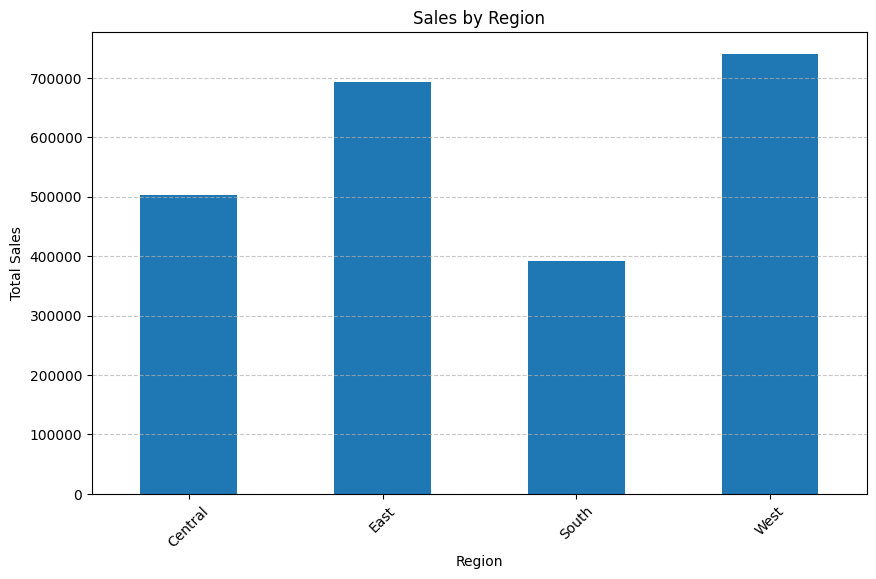

In [ ]:
# Plotting sales by region
plt.figure(figsize=(10, 6))
sales_by_region.plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Sales by Category
sales_by_category = df.groupby('Category')['Sales'].sum()
print('\nSales by Product Category:')
display(sales_by_category)


Sales by Product Category:


,Sales
Category,
Furniture,754747.7613
Office Supplies,731893.3140
Technology,839893.2790


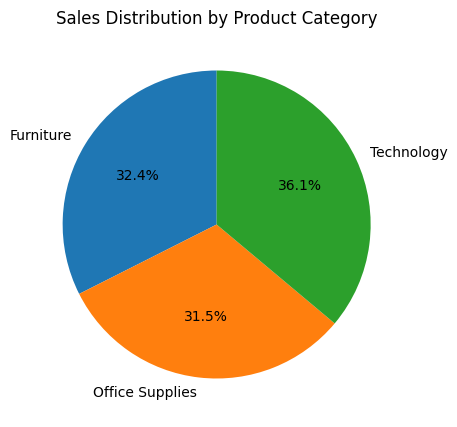

In [ ]:
# Plotting sales by category
plt.figure(figsize=(8, 5))
sales_by_category.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Sales Distribution by Product Category')
plt.ylabel('')
plt.show()

In [ ]:
# Sales by Sub-Category (top 10)
sales_by_subcategory = df.groupby('Sub-Category')['Sales'].sum().nlargest(10)
print('\nTop 10 Sales by Product Sub-Category:')
display(sales_by_subcategory)


Top 10 Sales by Product Sub-Category:


,Sales
Sub-Category,
Chairs,335768.2490
Phones,331842.6400
Storage,224644.5540
Tables,208020.1820
Binders,207354.8810
Machines,189925.0310
Accessories,167380.3180
Copiers,150745.2900
Bookcases,115361.2043


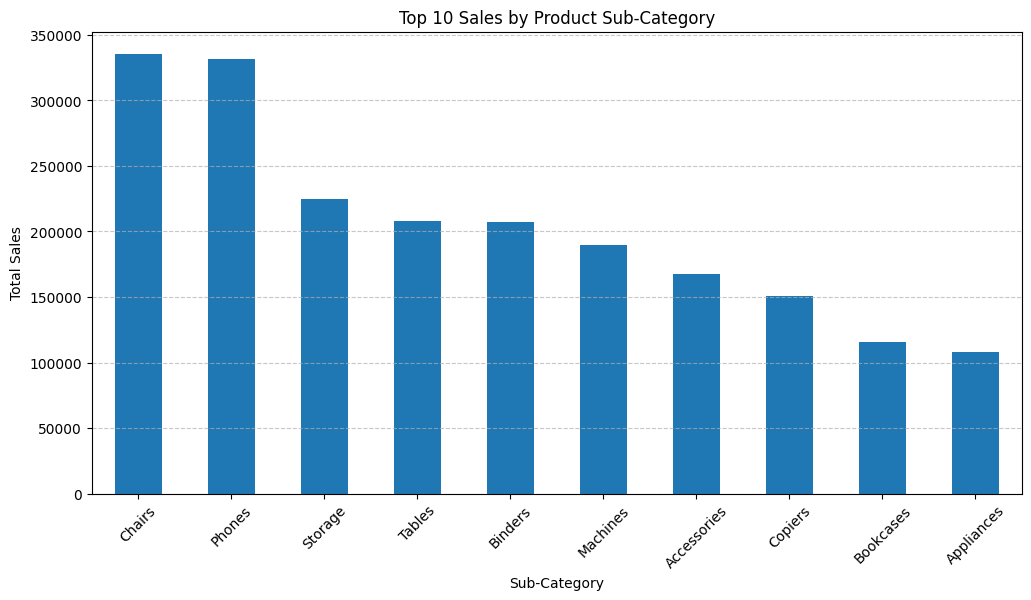

In [ ]:
# Plotting sales by sub-category
plt.figure(figsize=(12, 6))
sales_by_subcategory.plot(kind='bar')
plt.title('Top 10 Sales by Product Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()